In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)

In [2]:
df_loads_trips = pd.read_csv("../datos_transformados/df_loads_trips.csv", sep = ',')
df_loads_trips.shape

(85410, 21)

## <span style="color:orange">---------  Archivo *df_loads_trips.csv*  ---------<span>

Nº filas: 85410
Nº columnas: 21

### **<span style="color:orange">Descripción de las columnas que nos quedan<span>**

- **customer_id**: str, ID del cliente (CUST00000)
- **route_id**: str, ID de la ruta (RTE00000)
- **load_date**: str, Fecha de la carga (YYYY-MM-DD)
- **load_type**: str, Tipo de carga (Dry Van or Refrigerated)
- **weight_lbs**: int, Peso en libras de la carga
- **pieces**: int, número de bultos en la carga
- **revenue**: float, ingresos producidospor la carga
- **fuel_surchase**:  float, gastos de combustible
- **accesorial_charges**: float, cargos adicionales
- **booking_type**: str, tipo de contrato (Dedicated / Contract / Spot)
- **driver_id**: str, ID del empleado (DRV00000)
- **truck_id**: str, ID del camión (TRK00000)
- **trailer_id**: str, ID del trailer (TRL00000)
- **dispatch_date**: str, Fecha del envío (YYYY-MM-DD)
- **actual_distance_miles**: int, Distancia real en millas
- **actual_duration_hours**: float, Duración real en horas
- **fuel_gallons_used**: float, Galones de combustible utilizados
- **average_mpg**: float, Promedio de millas por galón utilizado
- **idle_time_hours**: float, Tiempo de inactividad en horas
- **trip_status**: str, todos los status son Completed (eliminar columna)
- **total_revenue**: float, resultado de (revenue - fuel_surcharge - accesorial_chargues)

<span style="color:orange">Estas son las columnas del resultado del merge de los dos principales archivos a analizar<span>

## <span style="color:orange">Outliers<span>
Visualización de outliers en variables numéricas mediante diagramas de caja

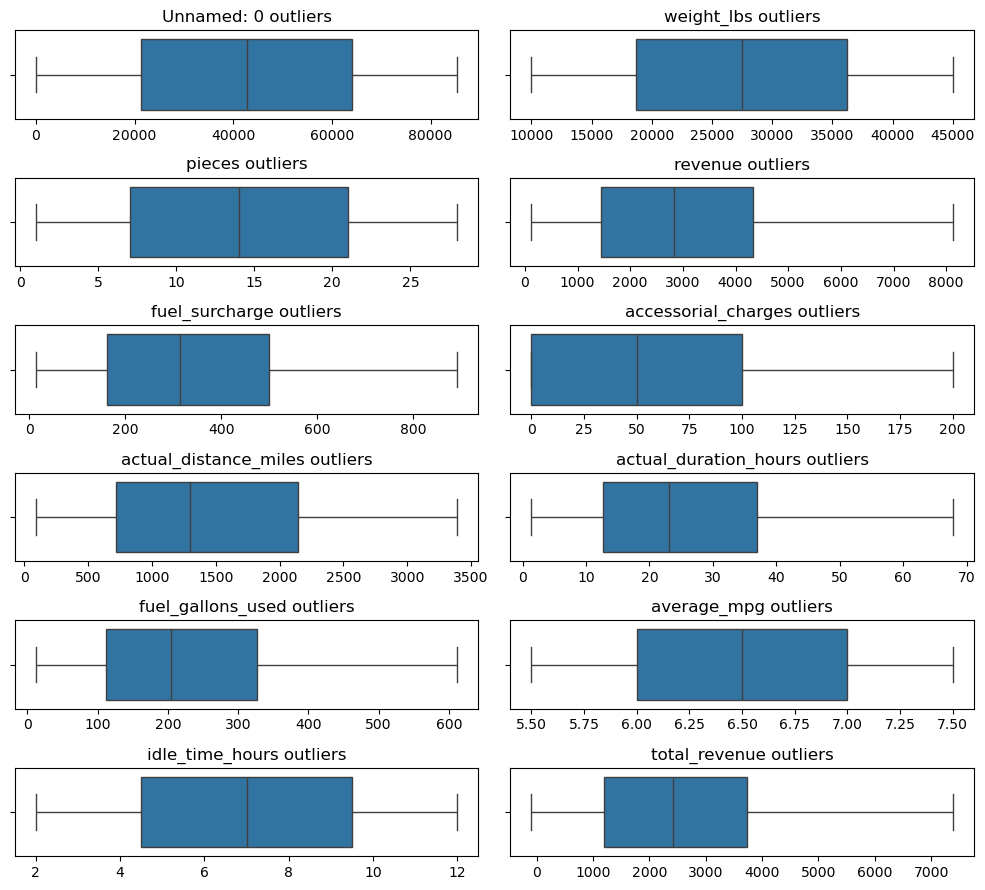

In [3]:
# Seleccionar solo columnas numéricas del DataFrame
df_num = df_loads_trips.select_dtypes(include=np.number)
cols_num = df_num.columns

# Calcular el número de gráficos y filas necesarias
n_plots = len(cols_num)
num_rows = math.ceil(n_plots / 2) # Se distribuyen en dos columnas

# Ajustar dinámicamente el tamaño de la figura
width = 5 * 2
height = 1.5 * num_rows
size = (width, height)

# Crear la estructura de subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=size)
axes = axes.flat

# Crear un boxplot para cada variable nunmérica
for i, col in enumerate(cols_num):
    sns.boxplot(
        x=col,
        data=df_num,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col} outliers')
    axes[i].set_xlabel('') # Eliminar etiqueta del eje x para mayor claridad
    
# eliminar el último gráfico si sobra un espacio vacío
if n_plots % 2 != 0:
    fig.delaxes(axes[-1])
    
# Ajustar el layput y mostrar la figura
plt.tight_layout()
plt.show()

<span style="color:orange">**No hay outliers en los datos**

In [4]:
df_loads_trips.columns

Index(['Unnamed: 0', 'customer_id', 'route_id', 'load_date', 'load_type',
       'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'booking_type', 'driver_id', 'truck_id',
       'trailer_id', 'dispatch_date', 'actual_distance_miles',
       'actual_duration_hours', 'fuel_gallons_used', 'average_mpg',
       'idle_time_hours', 'total_revenue'],
      dtype='object')

# <span style="color:orange">Matriz de correlación<span>
Vamos a echar un ojo al archivo de mayor tamaño y ver qué variables numnéricas tienen mayor relación entre si

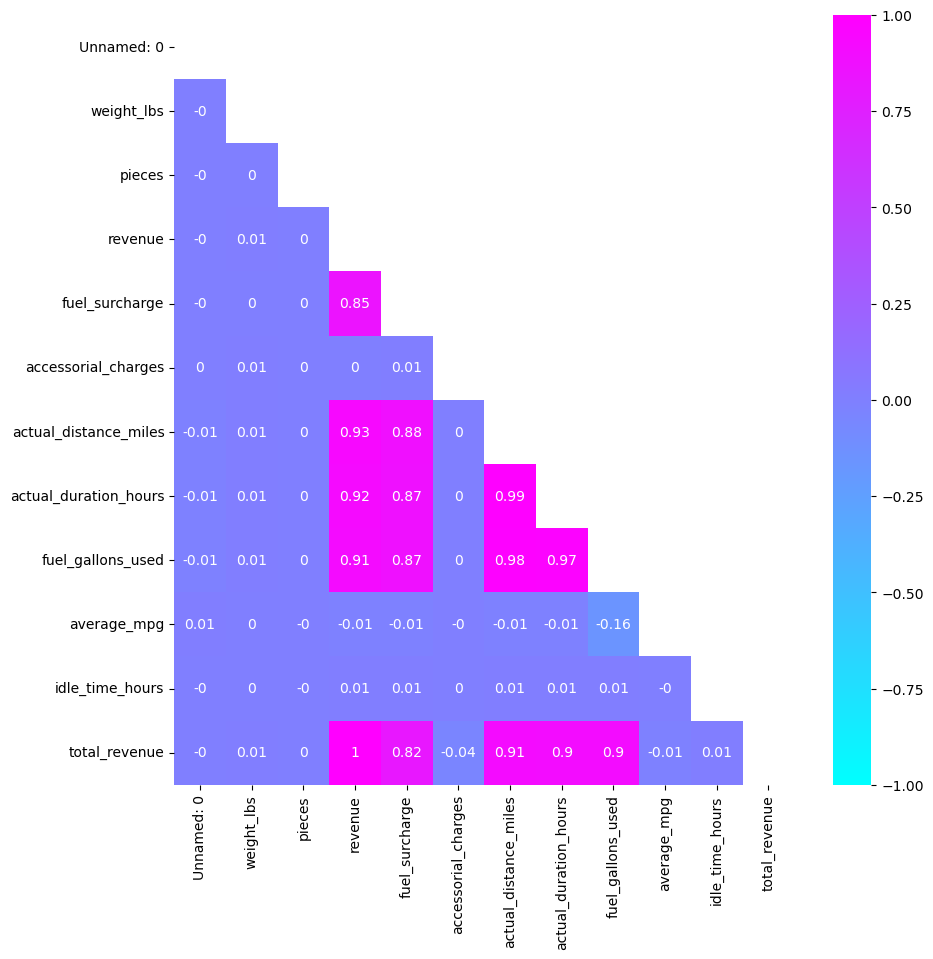

In [5]:
# Calcular matriz de correlación
corr_matrix = df_loads_trips.corr(numeric_only=True)

# Crear la figura
plt.figure(figsize=(10,10))

# Crear una máscara para mostrar solo la parte triangular
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Graficar el mapa de calor
sns.heatmap(
    corr_matrix.round(2),
    annot=True,
    vmin=-1,
    vmax=1,
    mask=mask,
    cmap='cool'
)

plt.show()

### Variables dónde hay mayor correlación:
Encontramos una correlación positiva fuerte entre las siguientes variables:
- **fuel_surcharge / revenue** (0.85): podemos entender que a mayor recargo por combustible, mayores ingresos, ya que viajes más largos serán más costosos para los clientes.
- **actual_distance_miles / revenue** (0.93): Al igual la anterior, viajes más largos = mayores beneficios.
- **actual_duration_hours / revenue*** (0.92): Muy ligada a las anteriores, mayor duración del viaje = mayores beneficios.
- **fuel_gallons_used / revenue*** (091): Muy ligada a las anteriores, más cantidad de galones de combustible utilizados = mayores beneficios
- **total_revenue / revenue*** (1): Correlación perfecta, tiene sentido, el total de los ingresos aumenta con los ingresos de cada viaje

- **actual_distance_miles / fuel_surcharge** (0.88): Viajes más largos = mayor recarga por combustible.
- **actual_duration_hours / fuel_sircharge** (0.87): Mayor duración del viaje = mayor recarga del combustible.
- **fuel_gallons_used / fuel_surcharge** (0.87): Más cantidad de galones de combustible utilizados = mayor recarga del combustible.
- **total_revenue / fuel_surcharge** (0.82): Mayor cantidad de ingresos totales = mayor recarga de combustible.
- **total_revenue / actual_distance_miles** (0.91): Mayor cantidad de ingresos totales = mayor distancia en millas del viaje.
- **total_revenue / actual_duration_hours** (0.90): Mayor cantidad de ingresos totales = mayor duraciçon en horas del viaje.
- **total_revenue / fuel_gallons_used** (0.90): Mayor cantidad de ingresos totales = mayor cantidad de galones de combistible utilizados.

- **actual_duration_hours / actual_distance_miles** (0.99): Correlación más alta, a maypor duración del viaje en horas, más distancia en millas.
- **fuel_gallons_used / actual_distance_miles** (0.98): Correlación muy alta, a mayor cantidad de galones utilizados, más distancia en millas.
- **fuel_gallons_used / actual_duration_hours** (0.97): Correlación muy alta, a mayor cantidad de galones utilizados, más duración en horas del viaje.

- **claim_amount / vehicle_damage_cost** (0.53): Hay correlación, aunque no tan alta, entre el importe de las reclamaciones y el coste del daño al camión, podríamos pensar que a más grave el incidente, más importe de reclamaciones hay.
- **claim_amount / cargo_damage_cost** (0.82): Correlación alta, mayor importe de las reclamaciones = mayor coste del daño en la carga durante el incidente.
- **total_maintenance_cost / number_of_maintenance** (0.87): Correlación alta, a mayor número de mantenimientos, mayor coste total de estos.

*Estas son las correlaciones positivas más fuertes encontradas en la matriz, en general todas tienen sentido, a viajes más largos, más cantidad de millas recorridas, mayor distancia, mayor coste del combistible y mayores beneficios.*
*Por otro lado, también hay correlación entre los incidentes y el coste de la reclamación, más notable cuando el daño es en la carga y no en el vehículo.*
*También reseñable que a mayor número de mantenimientos realizados a un camión, mayor coste total de estos.*

No se encuentran correlaciones negativas tan fuertes como las positivas.

Por nombrar alguna débiles:
- **average_mpg / fuel_gallons_used** (- 0.16): Cuando el Average MPG sube (más eficiencia), los galones utilizados bajan.
- **vehicle_damage_cost / weigth_lbs** (-0.15): Parece que cuando el tamaño del camión es más grande, el daño tiende a bajar, puede ser porque estén construidos con materiales más robustos y resistentes.
- **total_maintenance_cost / acquisition_mileage**: (-0.18): Hay una ligera tendencia, a que cuando el camión ha sido adquirido con un mayor número de millas, el coste del mantenimiento es menor (habría que revisar el tiempo que llevamos con el camión trabajando o las marcas de estos)

Hay más correlaciones negativas débiles que no vamos a entrar ahora a revisar, buscaremos patrones más adelante en los gráficos, podemos observar también que hay muchas variables que no tienen relación entre ellas.

# <span style="color:orange">Relaciones cruzadas
Variable objetivo numérico: <span style="color:orange">'total_revenue'

Vamos a analizar una de las variables importantes: *revenue*

Generamos gráficos de dispersión

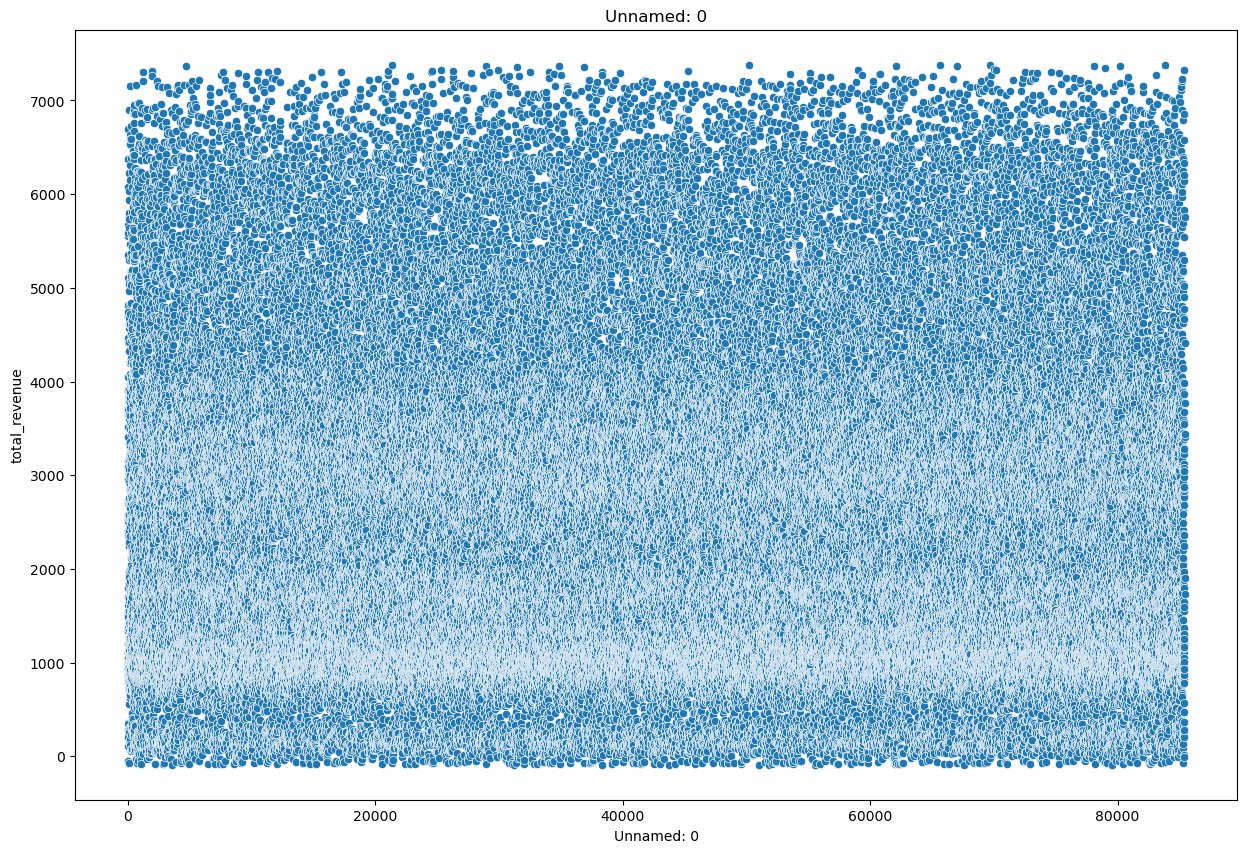

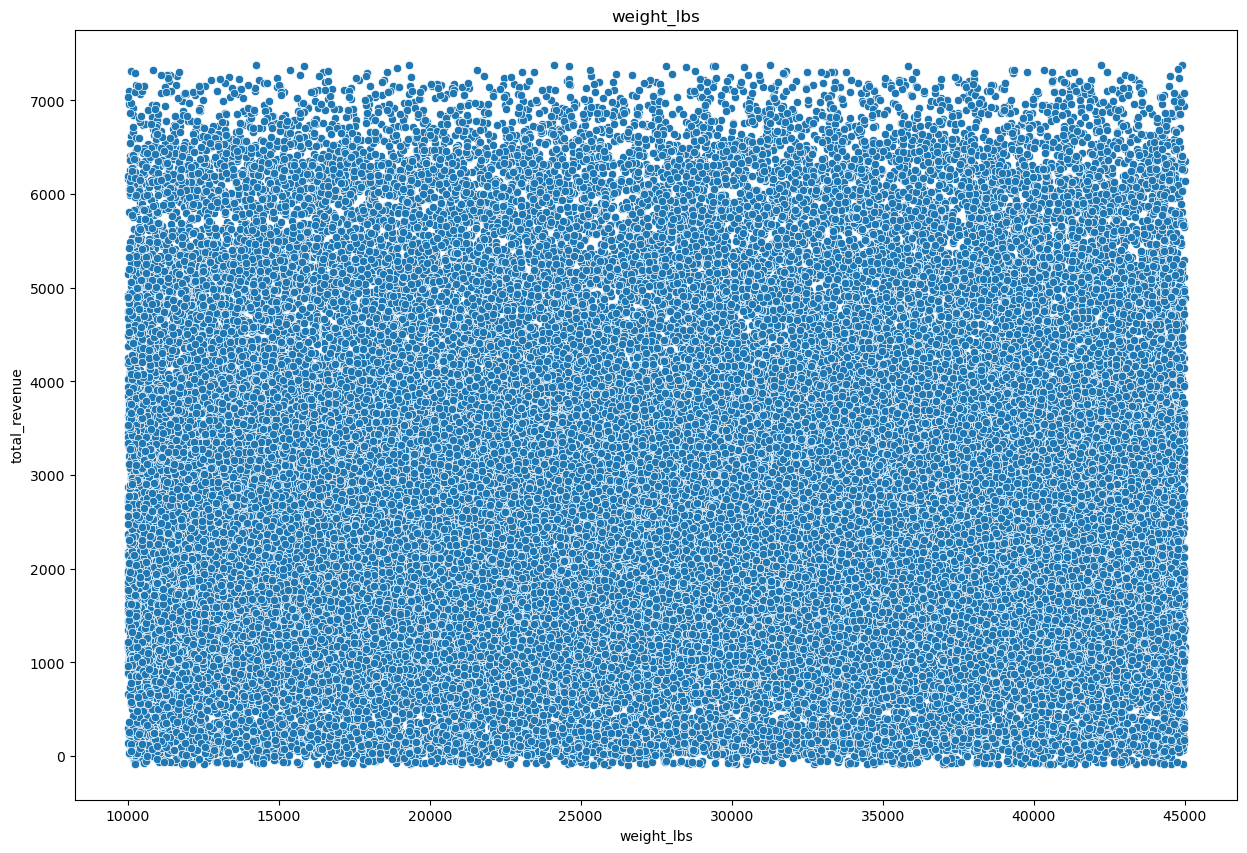

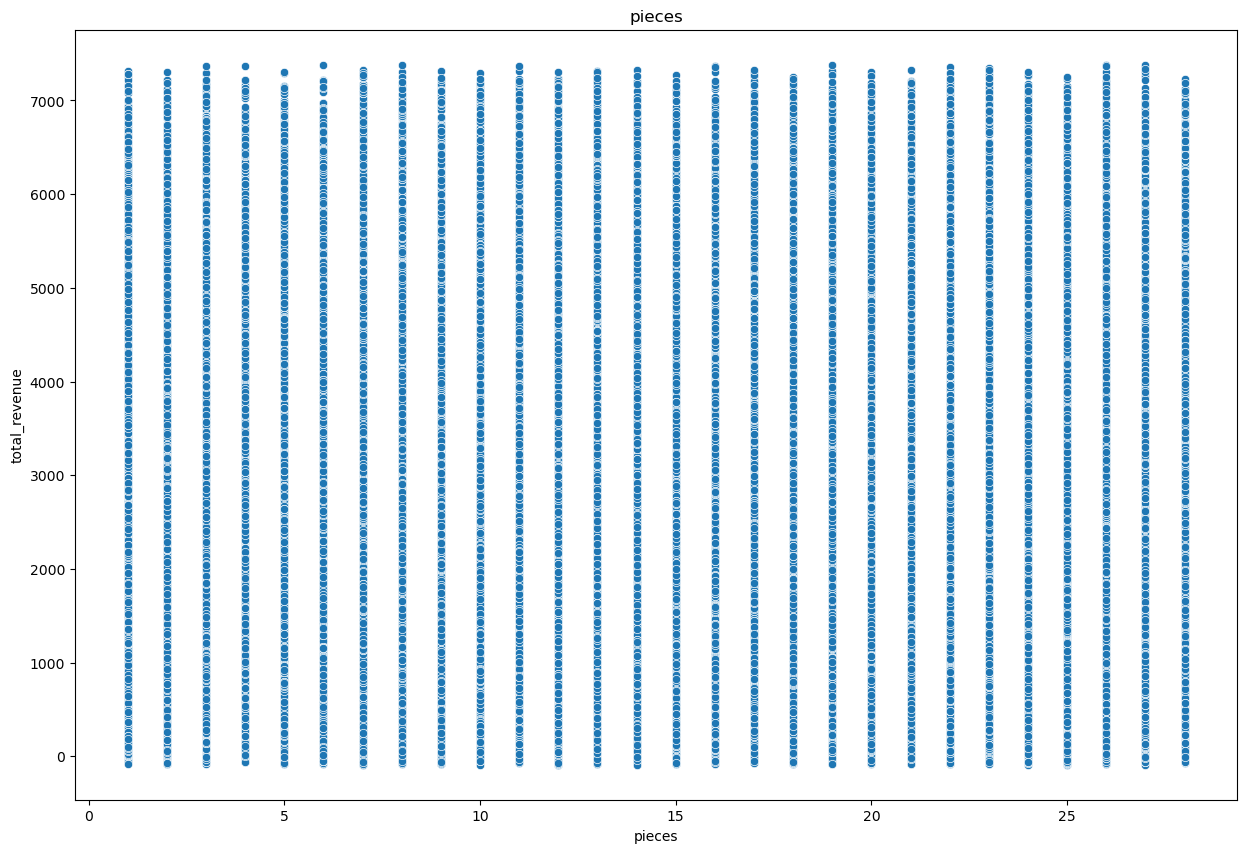

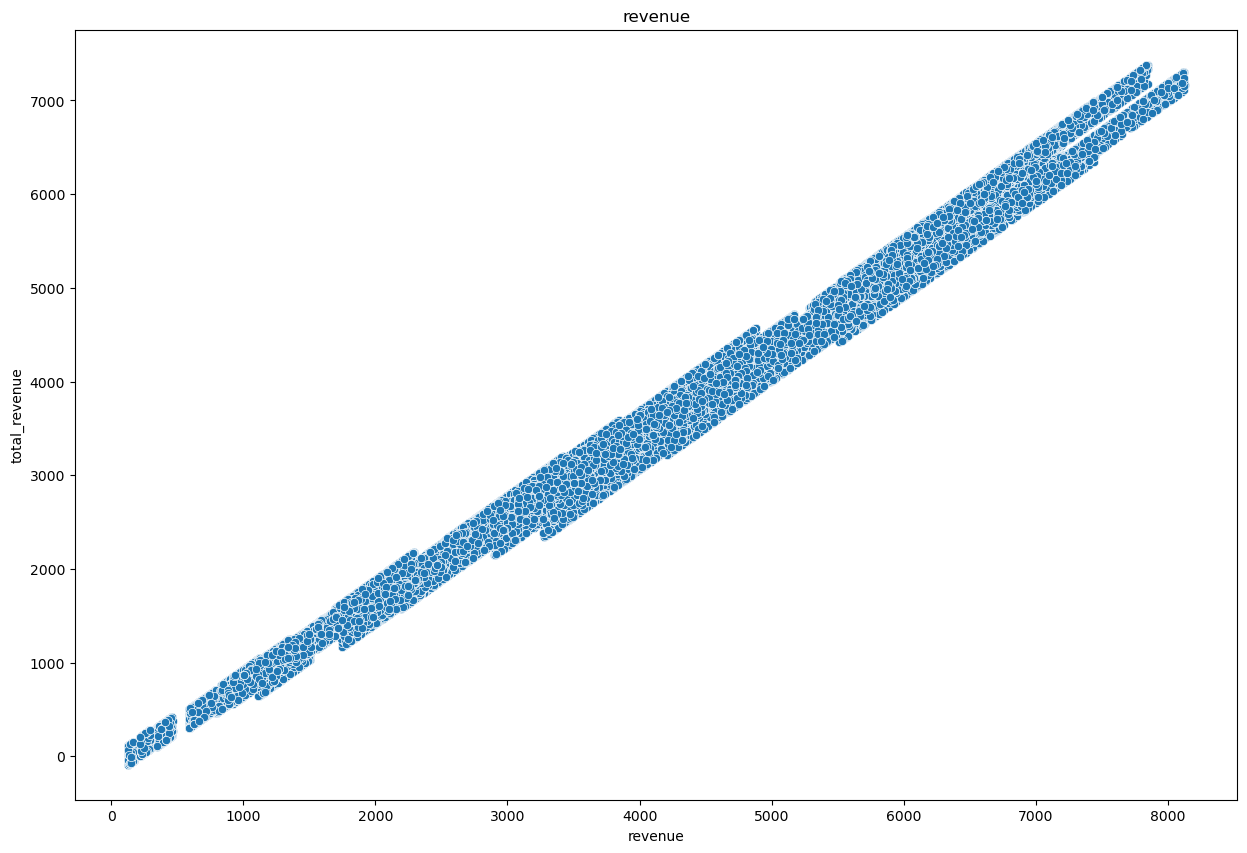

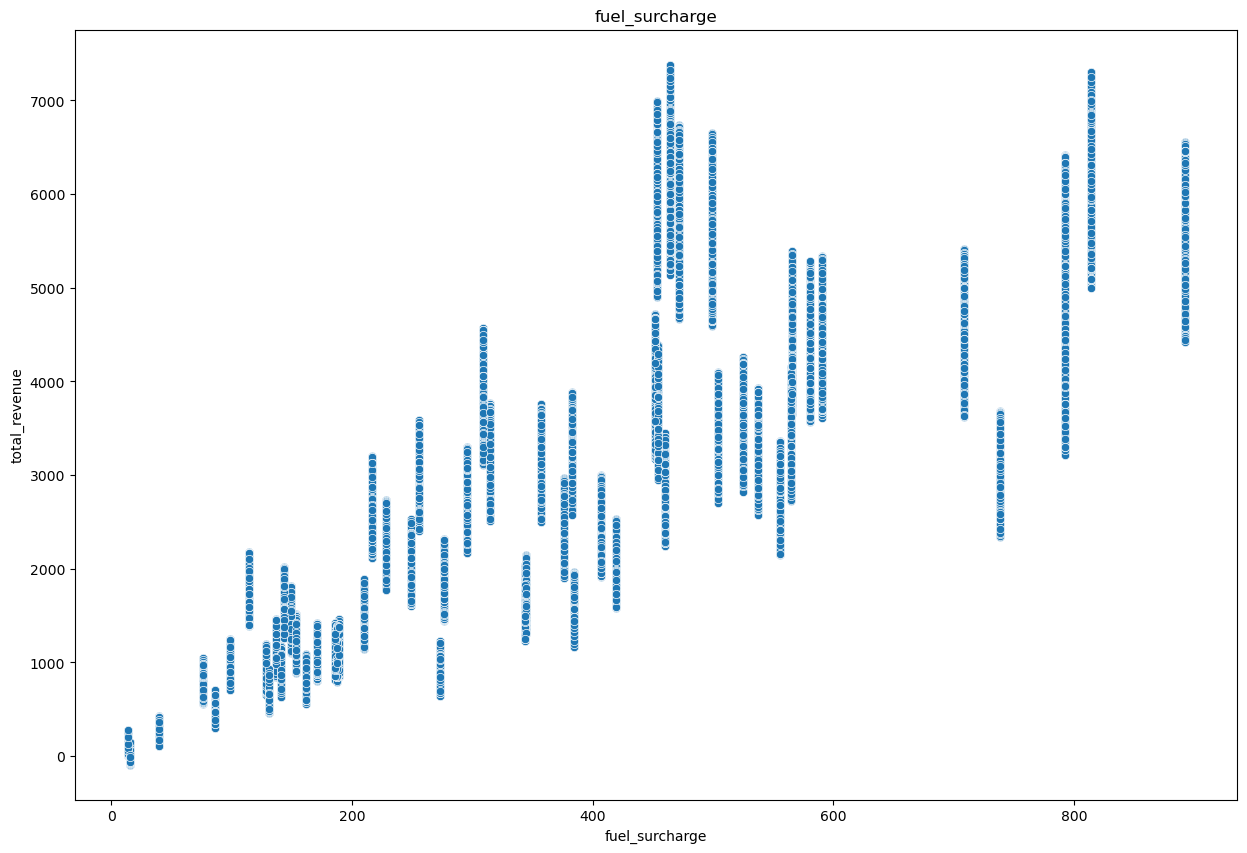

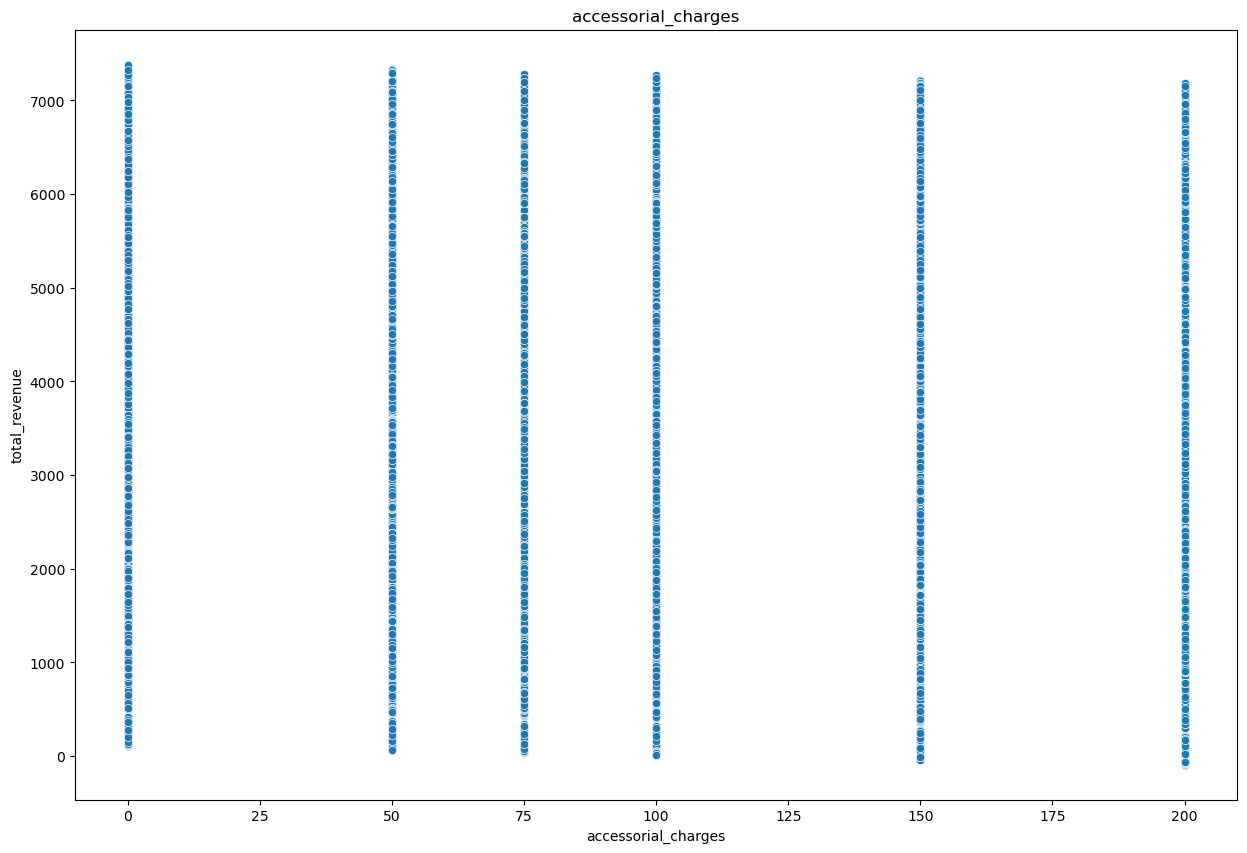

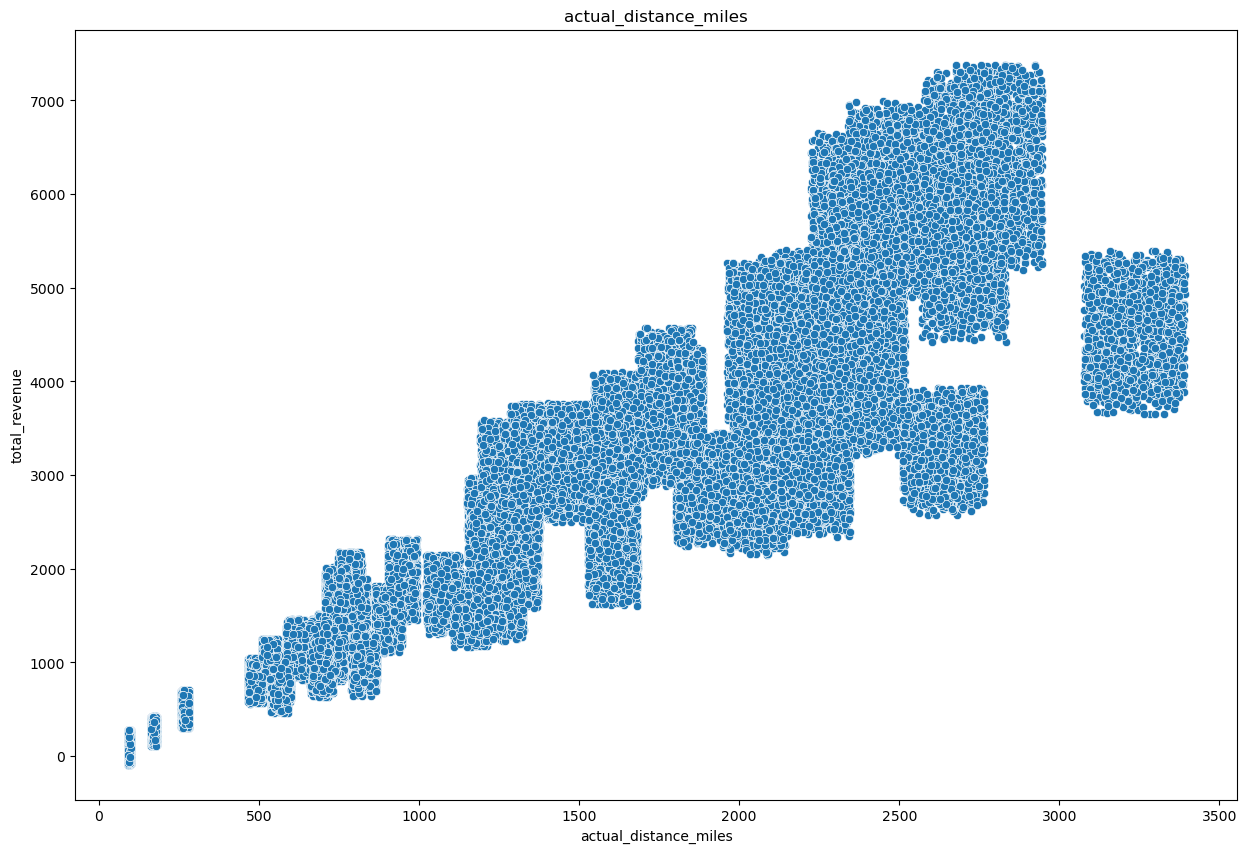

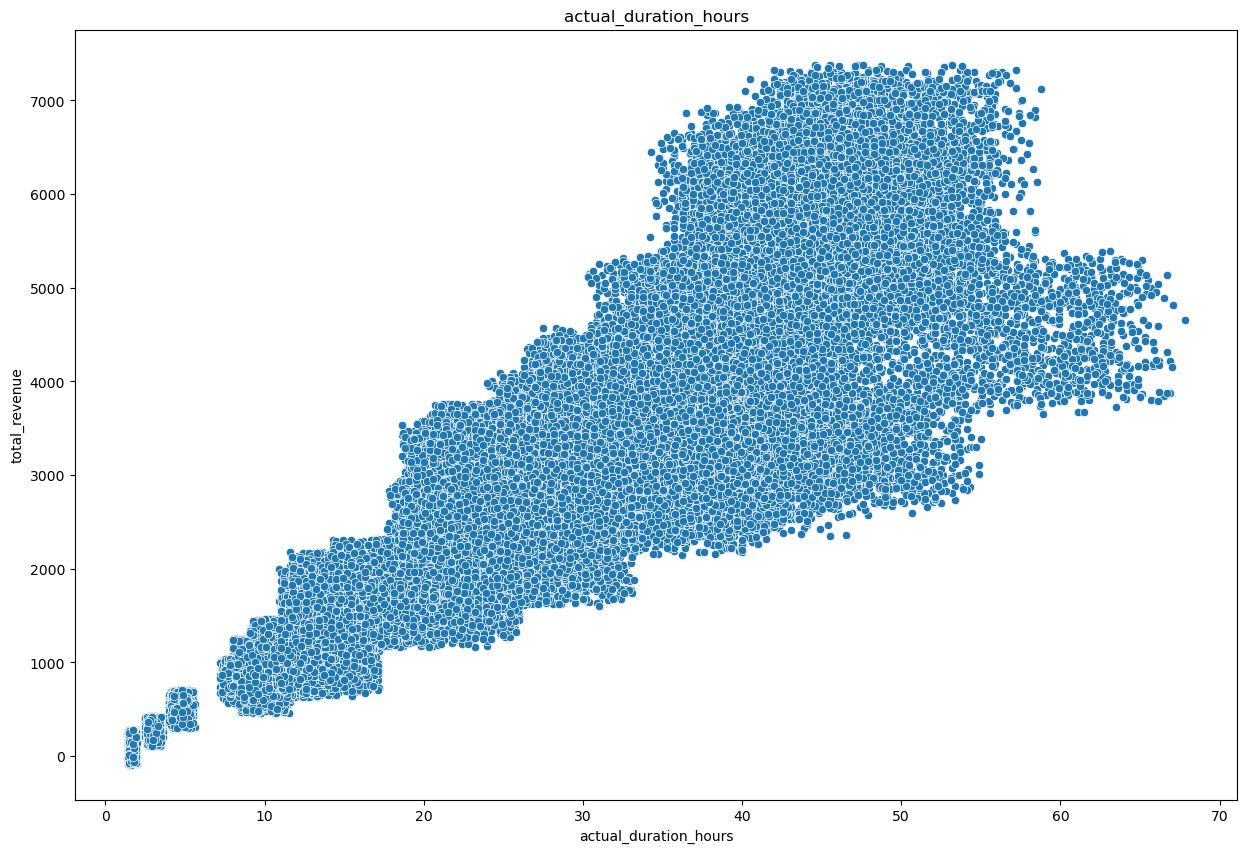

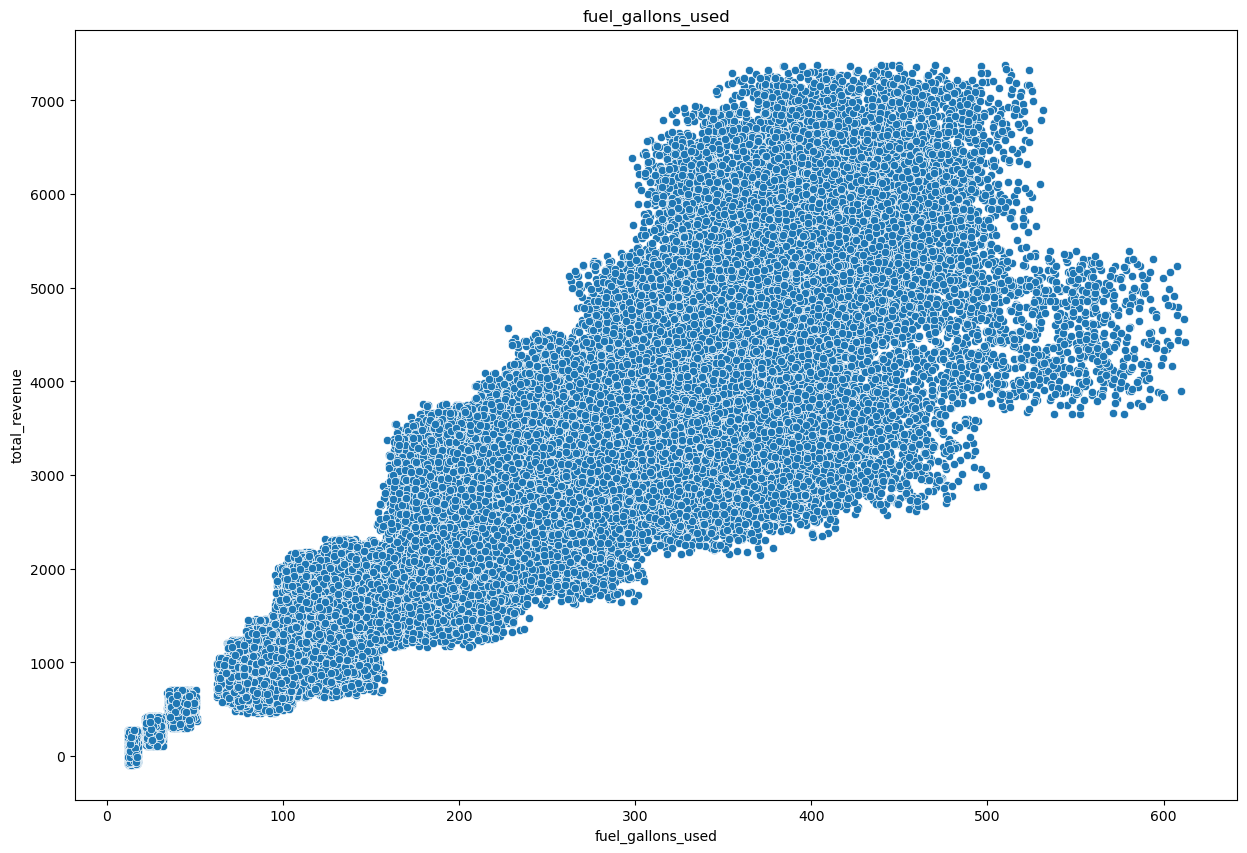

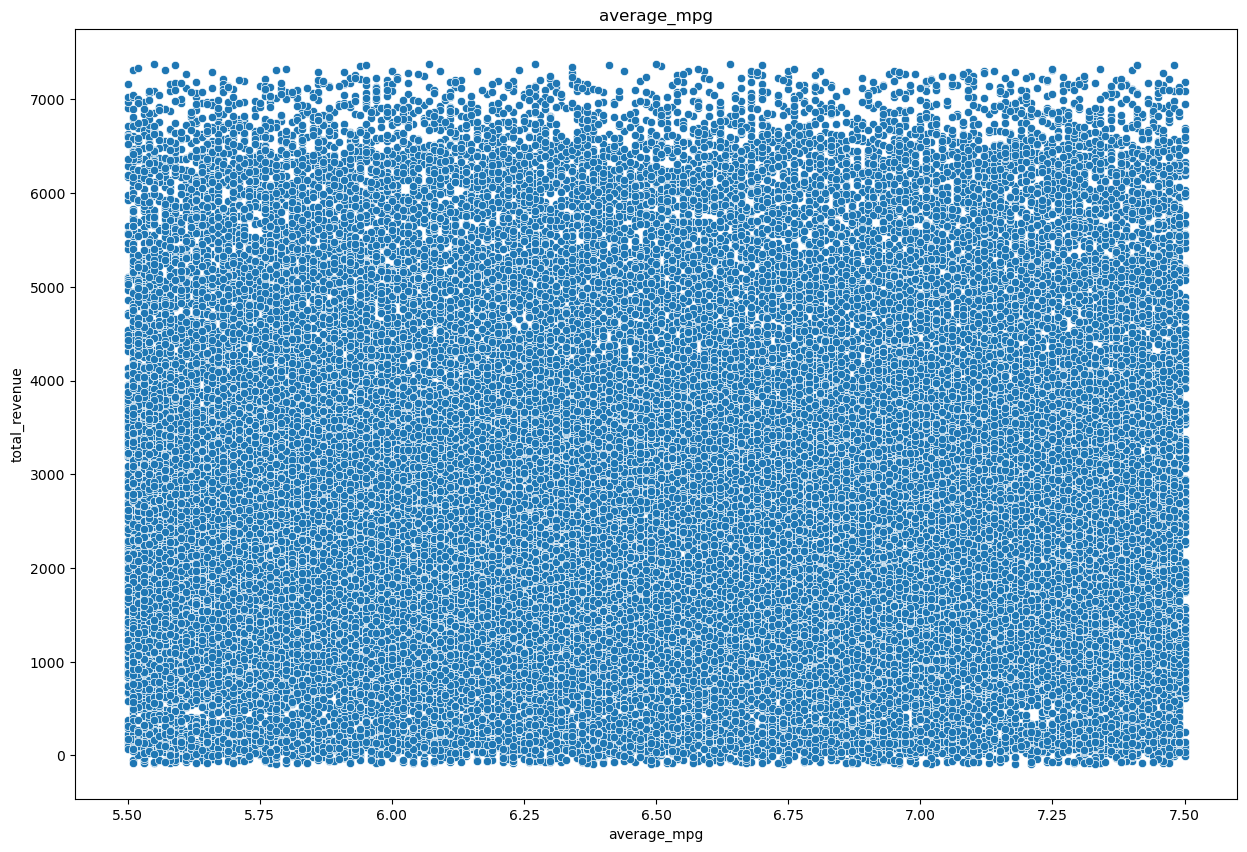

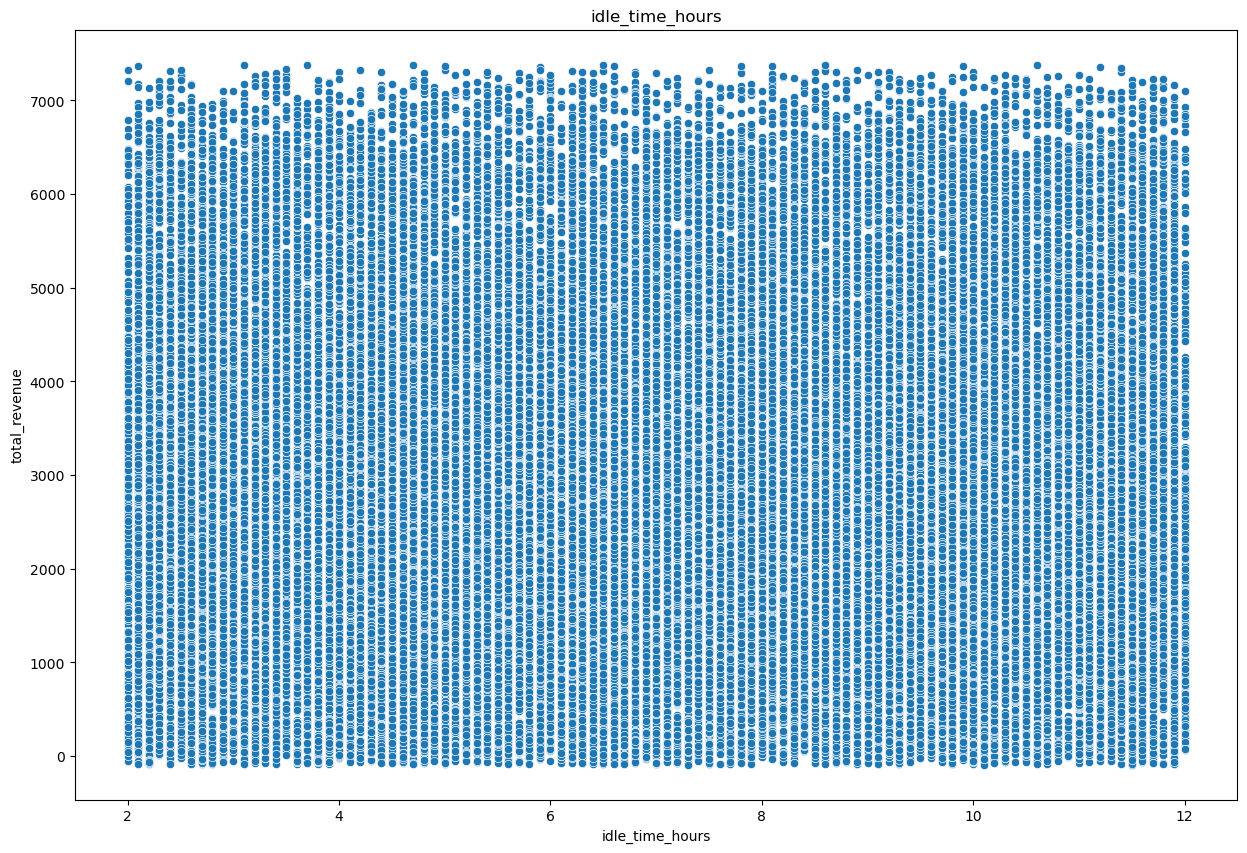

In [6]:
# Definir la variable objetivo
tv = 'total_revenue'

# Definir DataFrame y variables **NUMÉRICAS**
df_num = df_loads_trips.select_dtypes(include=np.number).drop(columns=[tv], errors='ignore')
cols_num = df_num.columns

# Generar gráficos de dispersión
def generar_grafico_dispersion(tv, col, hue=None):
    """Función para generar gráficos de dispersión

    Args:
        tv (string): nombre de la variable objetivo
        col (string): nombre de la columna que queremos graficar
        hue (string, optional): nombre de la tercera variable a analizar. Defaults to None.
    """
    plt.figure(figsize=(15,10))
    
    if hue == None:
        sns.scatterplot(x=df_loads_trips[col], y=df_loads_trips[tv])
    else:
        sns.scatterplot(x=df_loads_trips[col], y=df_loads_trips[tv], hue=df_loads_trips[hue], alpha=0.3, palette='Blues')
    
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.show()
    
# Buscamos gráfico a gráfico y confirmamos los patrones vistos anteriormente
for col in df_num:
    generar_grafico_dispersion(tv, col)

<span style="color:orange">Podemos confirmar las correlaciones vistas anteriormente, pero vamos a explorar un poco más

# <span style="color:orange">Gráfico Lineal


In [7]:
df_loads_trips.sample(2)

,Unnamed: 0,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,booking_type,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,total_revenue
10365,10365,CUST00108,RTE00055,2022-05-13,Refrigerated,28617,16,3629.46,357.25,0,Contract,DRV00141,TRK00011,TRL00128,2022-05-13,1523,30.5,208.9,7.29,7.2,3272.21
41797,41797,CUST00106,RTE00049,2023-06-21,Dry Van,15903,23,1723.12,144.00,75,Spot,DRV00006,TRK00002,TRL00086,2023-06-21,767,12.1,127.0,6.04,3.5,1504.12


### <span style="color:orange">total_revenue vs algunas variables
<span style="color:orange">Aquí podemos ver una fuerte correlación lineal, entre la variables analizadas y el total de ingresos, aunque con los tres vemos una tendencia a la baja hacia los valores más altos de total_revenue, esto podría deberse a algún tipo de tarifa de descuento que se aplique a los viajes más largos ¿?

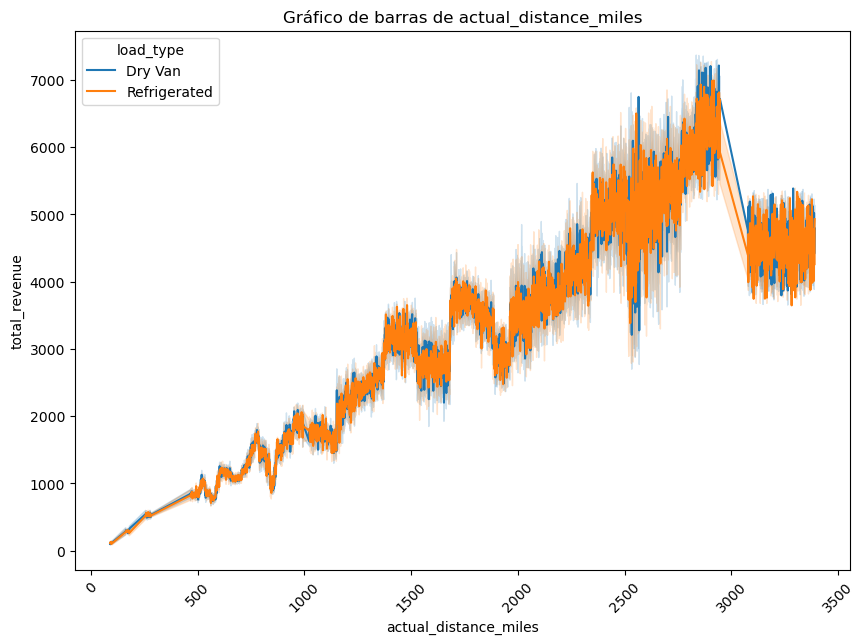

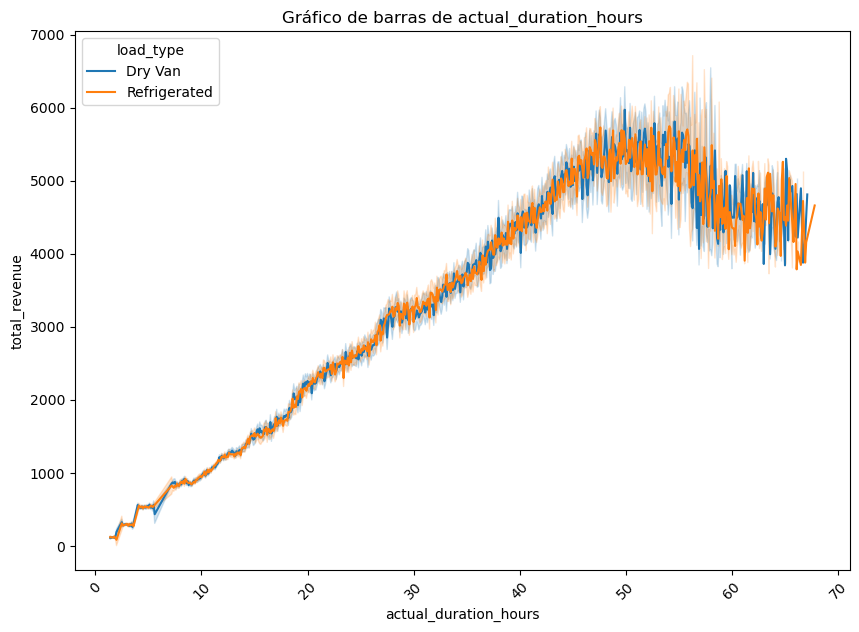

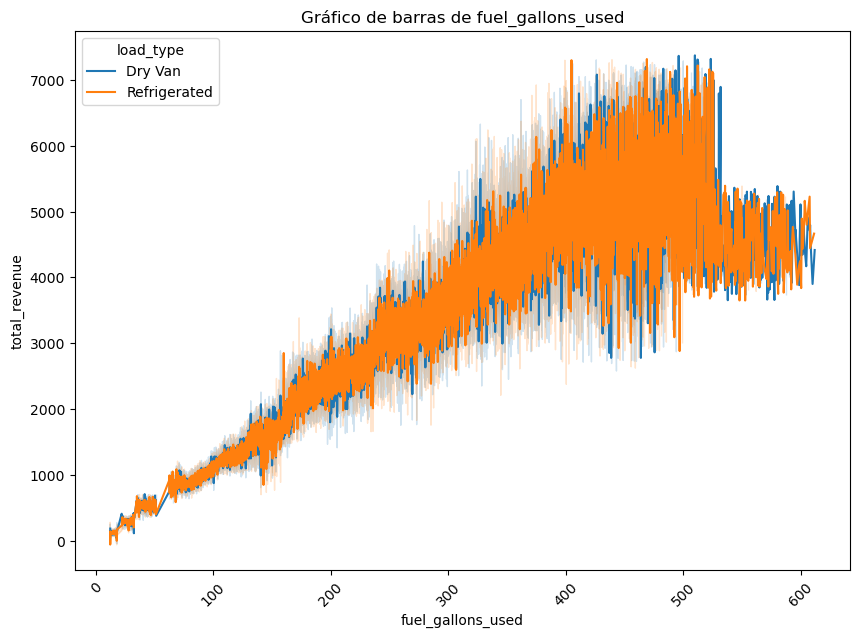

In [8]:
tv = 'total_revenue'
columns = ['actual_distance_miles', 'actual_duration_hours', 'fuel_gallons_used']

for col in columns:
    width = 10
    height = 7

    plt.figure(figsize=(width, height))
    sns.lineplot(data=df_loads_trips, x=df_loads_trips[col], y=df_loads_trips[tv], hue=df_loads_trips['load_type'])

    plt.title(f'Gráfico de barras de {col}')
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.xticks(rotation=45)

    plt.show()

# <span style="color:orange">Gráficos categóricos<span>
<span style="color:orange">Lo más reseñable que encontramos es que hay ventaja de los contratos tipo Dedicated

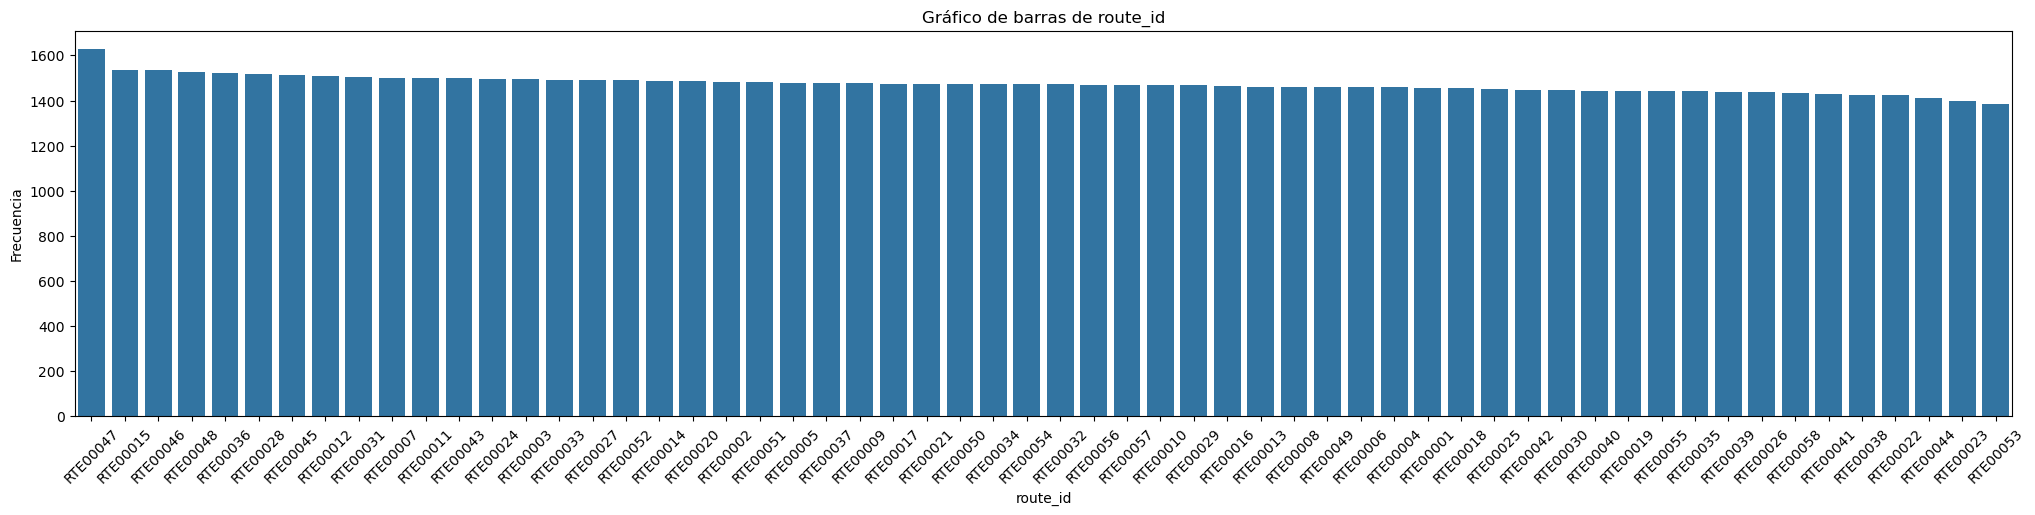

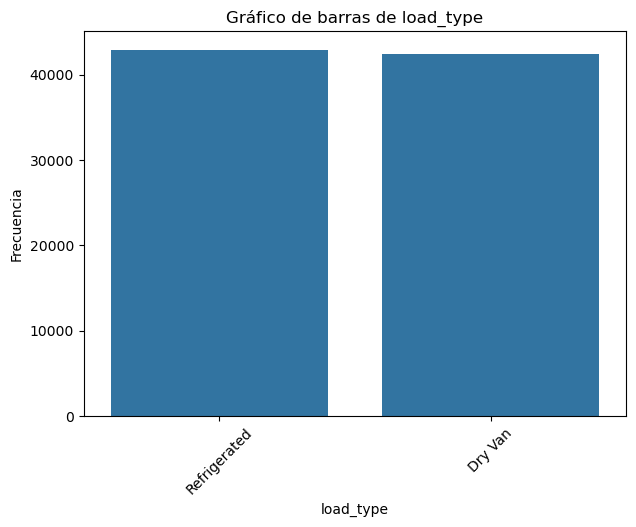

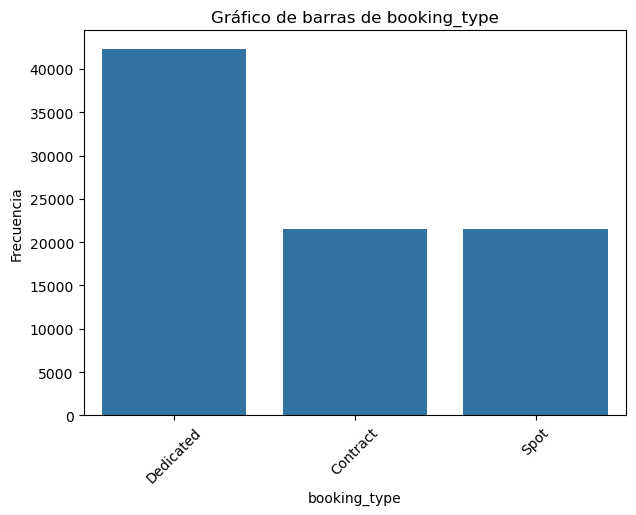

In [9]:
# Seleccionamos las que tienen pocas categorías
cat_cols = ['route_id', 'load_type', 'booking_type']

for col in cat_cols:
    num_categories = df_loads_trips[col].nunique()
    width = max(7, min(num_categories * 0.5, 25))
    height = 5 # altura fija
    
    plt.figure(figsize=(width, height))
    sns.countplot(x=df_loads_trips[col], order=df_loads_trips[col].value_counts().index)
    
    plt.title(f'Gráfico de barras de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    
    plt.show()

<span style="color:orange">Aunque el porcentaje de estos (Dedicated) no parece influir en si la carga es Refrigerated o Dry Van

In [10]:
# Agrupar los datos por load_type y booking_type
sunburst_data = df_loads_trips.groupby(['load_type', 'booking_type']).size().reset_index(name='Count')

# Crear el gráfico Sunburst
fig = px.sunburst(sunburst_data, 
                  path=['load_type', 'booking_type'],
                  values='Count', 
                  title="Sunburst Chart for Load Type y Booking Type")

fig.update_layout(
    width=600,
    height=600
)
# Mostrar el gráfico
fig.show()